# Sistemas Dinámicos

**Módulo 4 — Sistemas Dinámicos y Solución Numérica de EDOs**

**Programación Científica 2026-1 · Universidad Nacional de Colombia**  
mbastidaso@unal.edu.co

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/)

---

Este notebook implementa y visualiza un modelo de dinámica social:Daley-Kendall, variante Maki-Thompson

Se resuelve con **Euler explícito**, **Runge-Kutta de orden 4 (RK4)** y con 
`scipy.integrate`, y su función principal para resolver un PVI que es
`solve_ivp`.

In [1]:
# ── Instalación de LaTeX para renderizado tipográfico (descomentar en Colab) ──
#!sudo apt-get update -qq
#!sudo apt-get install -qq texlive-latex-extra texlive-fonts-recommended dvipng cm-super

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import brentq

# ── Configuración global de estilo matplotlib ────────────────────────────────
plt.rcParams.update({
    "text.usetex"        : True,
    "font.family"        : "serif",
    "font.serif"         : ["Computer Modern Roman"],
    "font.size"          : 14,

    "axes.labelsize"     : 16,
    "axes.titlesize"     : 18,
    "xtick.labelsize"    : 12,
    "ytick.labelsize"    : 12,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction"    : "in",
    "ytick.direction"    : "in",

    "grid.color"         : "gray",
    "grid.linewidth"     : 0.3,
    "grid.alpha"         : 0.3,
    "grid.linestyle"     : "--",

    "figure.dpi"         : 120,
    "axes.spines.top"    : False,
    "axes.spines.right"  : False,
    "savefig.bbox"       : "tight",
    "savefig.dpi"        : 300,
})
print("Configuración OK")


Configuración OK


---
## Parte 1 — El modelo

Tres estados: ignorante ($i$), difusor ($s$), cansado ($r$), con
$i+s+r=1$:

$$
\dot i = -\beta i s, \qquad
\dot s = \beta i s - \alpha s(s+r), \qquad
\dot r = \alpha s(s+r).
$$

In [ ]:
# ── RHS del modelo DK ──────────────────────────────────────────────────────
def dk_rhs(t, x):
       """
       Lado derecho del modelo del chisme, con la firma f(t, x, ...)
       que exige scipy.integrate (tiempo primero, estado después).
       """
       i, s, r = x
       di = -beta * i * s
       ds =  beta * i * s - alpha * s * (s + r)
       dr =  alpha * s * (s + r)
       return [di, ds, dr]


# ── Euler explícito ─────────────────────────────────────────────────────────
def euler(f, x0, t, **kw):
    """
    Integrador de Euler explícito de primer orden.
    x_{n+1} = x_n + Δt · f(x_n, t_n)

    Parámetros
    ----------
    f   : callable f(x, t, **kw) — campo vectorial
    x0  : (N,) ndarray            — condición inicial
    t   : (M,) ndarray            — tiempos de salida
    **kw: parámetros extra para f

    Retorna
    -------
    X : (M, N) ndarray — trayectoria aproximada
    """
    X    = np.zeros((len(t), len(x0)))
    X[0] = x0
    for n in range(len(t) - 1):
        ...
    return X


# ── Runge-Kutta de orden 4 ───────────────────────────────────────────────────
def rk4(f, x0, t, **kw):
    """
    Integrador de Runge-Kutta de orden 4.
    Promedia cuatro evaluaciones de f para alcanzar error local O(Δt⁵).

    Parámetros
    ----------
    f   : callable f(x, t, **kw) — campo vectorial
    x0  : (N,) ndarray            — condición inicial
    t   : (M,) ndarray            — tiempos de salida
    **kw: parámetros extra para f

    Retorna
    -------
    X : (M, N) ndarray — trayectoria aproximada
    """
    X    = np.zeros((len(t), len(x0)))
    X[0] = x0
    for n in range(len(t) - 1):
        ...
    return X


print("Funciones definidas: dk_rhs, euler, rk4")



Funciones definidas: hk_rhs, euler, rk4


---
## Parte 2 — Resolver con euler y RK4

Se resuelve el problema: $\beta=2.0$, $\alpha=1.0$,
$i_0=0.99$, $s_0=0.01$, $r_0=0$, hasta $T=15$.

In [5]:
# ── Convergencia de Euler y RK4 en el modelo H-K ────────────────────────────
# Se usa una condición inicial pequeña fija y un epsilon donde la dinámica
# es suave para que la comparación sea limpia.

beta, alpha = 2.0, 1.0
x0_chisme   = [0.99, 0.01, 0.0]
T           = 15.0

# Solución de referencia: RK4 con paso muy pequeño
dt_ref   = 1e-4
t_ref    = np.arange(0, T_c + dt_ref, dt_ref)
X_ref    = # Si no hay solucion analítica entonces con quién se compara?
x_end    = X_ref[-1]  # estado final de referencia

# Barrido de pasos de tiempo
dts      = # Donde vamos a medir el error?
err_eu   = []   # errores de Euler
err_rk   = []   # errores de RK4

for dt_ in dts:
    t_ = np.arange(0, T_c + dt_, dt_)

    # Error de Euler: norma del estado final vs referencia
    Xe = ...
    err_eu.append(np.linalg.norm(Xe[-1] - x_end))

    # Error de RK4
    Xr = ...
    err_rk.append(np.linalg.norm(Xr[-1] - x_end))

dts_arr = np.array(dts)

fig, ax = plt.subplots(figsize=(7, 5))

# Errores de cada método

# Rectas de referencia teóricas (pendientes 1 y 4)
ax.loglog(dts_arr, 0.30 * dts_arr**1, "k--", lw=1, alpha=0.5, label="pendiente 1")
ax.loglog(dts_arr, 0.08 * dts_arr**4, "k:",  lw=1, alpha=0.5, label="pendiente 4")

ax.set_xlabel(r"Paso de tiempo $\Delta t$")
ax.set_ylabel(r"Error $\|x(T) - x_{\rm ref}(T)\|_2$")
ax.set_title(r"Convergencia: Euler vs.\ RK4 en el modelo DK")
ax.legend(framealpha=0.9)
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()


SyntaxError: invalid syntax (462046936.py, line 12)

---
## Parte 3 — Primera llamada a `solve_ivp`


```python
solve_ivp(fun, t_span, y0, method='RK45', t_eval=None, args=(), **opciones)
```

- `fun`: el campo vectorial. **Ojo:** scipy espera `fun(t, y)`, con el
  tiempo *primero* — al revés de como lo escribieron ustedes hasta
  ahora (`f(x, t, **kw)`). Es la convención estándar en toda la
  biblioteca `scipy.integrate`, y es la causa más común de errores al
  reutilizar código propio con `solve_ivp`.
- `t_span`: una tupla `(t0, tf)`, no un arreglo de tiempos. `solve_ivp`
  decide **por sí solo** en qué instantes evaluar, con paso variable.
- `y0`: la condición inicial.
- `method`: el algoritmo. Por defecto es `'RK45'` — un Runge-Kutta de
  orden 4(5) con **paso adaptativo**, muy distinto del RK4 de paso fijo
  que programaron a mano.
- `t_eval` (opcional): si quieren la solución evaluada en instantes
  específicos (por ejemplo, para graficar en una malla uniforme), se
  los pasan aquí. Si no, `solve_ivp` devuelve solo los instantes que
  eligió internamente.
- `args`: los parámetros extra del modelo (`beta`, `alpha`), como una
  **tupla posicional** — no como `**kwargs`.

In [ ]:
sol = solve_ivp(
    fun=dk_rhs,
    t_span=(0.0, T),
    y0=x0_chisme,
    method="RK45",
    args=(beta, alpha),
)

print("¿Convergió exitosamente?:", sol.success)
print("Mensaje del solver     :", sol.message)
print("Número de instantes que solve_ivp eligió solo:", len(sol.t))
print("Forma de sol.t:", sol.t.shape)
print("Forma de sol.y:", sol.y.shape")

¿Convergió exitosamente?: True
Mensaje del solver     : The solver successfully reached the end of the integration interval.
Número de instantes que solve_ivp eligió por sí solo: 16
Forma de sol.t: (16,)
Forma de sol.y: (3, 16)  <- OJO: (n_variables, n_tiempos), transpuesto respecto a lo que usaban antes


**Importante:** `sol.y` tiene forma
`(n_variables, n_tiempos)` — cada **fila** es una variable de estado a
lo largo del tiempo.

---
## Parte 4 — ¿Qué significa "paso adaptativo"?

Con Euler/RK4 de paso fijo, ustedes elegían un $h$ y lo usaban en toda
la simulación. `solve_ivp` hace algo distinto: en cada paso, estima el
error local y **ajusta el tamaño del siguiente paso** — pasos pequeños
donde la solución cambia rápido, pasos grandes donde cambia lento.

Se puede ver esto directamente graficando los tamaños de paso que usó
internamente (`np.diff(sol.t)`), sin pasar `t_eval`.

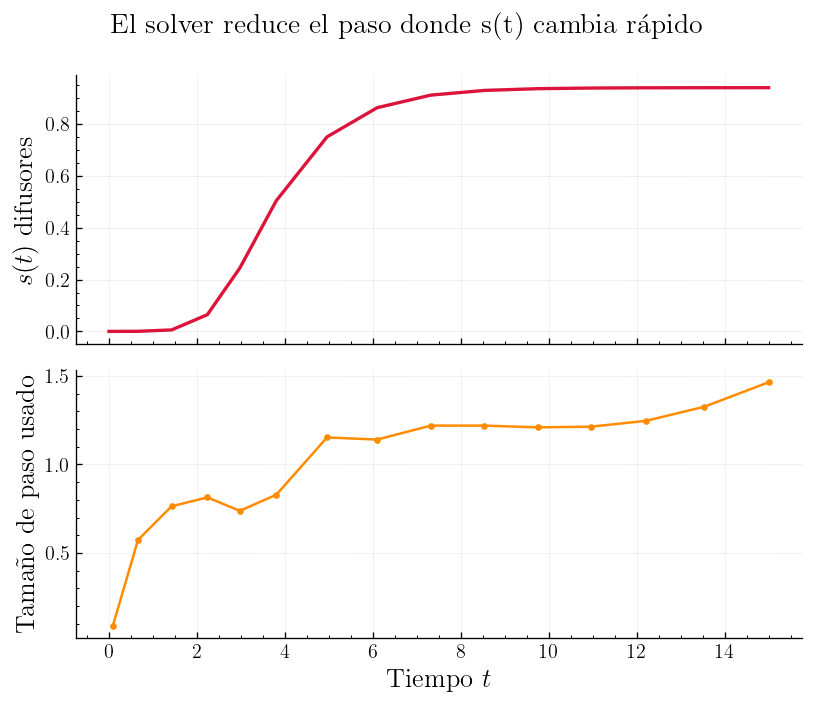

In [ ]:
pasos = np.diff(sol.t)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), sharex=True)

ax1.plot(sol.t, sol.y[1], lw=2, color="crimson")
ax1.set_ylabel(r"$s(t)$ difusores")
ax1.grid(True)

ax2.plot(sol.t[1:], pasos, "o-", ms=3, color="darkorange")
ax2.set_xlabel(r"Tiempo $t$")
ax2.set_ylabel(r"Tamaño de paso usado")
ax2.grid(True)

plt.suptitle("El solver reduce el paso donde s(t) cambia r\u00e1pido")
plt.tight_layout()
plt.show()


---
## Parte 5 — Otros métodos disponibles

`method` acepta varios algoritmos, no solo `'RK45'`:

| Método | Tipo | Cuándo usarlo |
|---|---|---|
| `RK45` (por defecto) | Runge-Kutta orden 4(5) | uso general, la mayoría de los casos |
| `RK23` | Runge-Kutta orden 2(3) | menos preciso pero más rápido |
| `DOP853` | orden 8 | cuando se necesita muy alta precisión |

El modelo del chisme no es rígido, así que `RK45` (el que ya usamos)
es la elección natural. 

**Observación:** pedir más precisión (`rtol`, `atol` más pequeños)
obliga al solver a usar más pasos, pero el resultado final converge —
exactamente el mismo principio de convergencia que vieron con Euler y
RK4 de paso fijo, solo que aquí el solver decide cuántos pasos hacen
falta en vez de que ustedes se lo digan.

---
## Parte 6 — Verificación de conservación

Como siempre, se verifica que $i(t)+s(t)+r(t)=1$ se mantenga a lo
largo de toda la trayectoria calculada por `solve_ivp`.

In [ ]:
suma_euler = ...
suma_rk4 = ...
suma = sol.y.sum(axis=0)   # suma sobre las 3 variables, para cada tiempo

print("Máxima desviación de i+s+r respecto a 1:", np.max(np.abs(suma - 1.0)))
assert np.allclose(suma, 1.0, atol=1e-6), "La conservación no se cumple"
print("OK: i(t)+s(t)+r(t)=1 se conserva a lo largo de toda la simulación.")


Máxima desviación de i+s+r respecto a 1: 4.440892098500626e-16
OK: i(t)+s(t)+r(t)=1 se conserva a lo largo de toda la simulación.


## Ejercicio: ¿Por qué el chisme nunca llega al 100%?